# Mauna Loa CO₂ analysis

## Introduction

This notebook contains an analysis of the Mauna Loa dataset from the `statsmodels` package.

### What is the dataset?

The dataset records the **weekly average concentrations of atmospheric CO₂** at the site of the Mauna Loa volcano in Hawaii over the period spanning from March 1958 to December 2001.

Continuous measurements were taken four times per hour using a nondispersive infrared gas analyzer from atop several observation towers.  Steady data periods of not less than six hours per day were required; if no such six-hour periods were available on a given day, then no reading was registered for that day.

### Why is the dataset useful?

Observation sites situated on Mauna Loa are commonly used to monitor background atmospheric CO₂ because of its remote, high-altitude location.

This enables the sampling of well-mixed air with relatively little local influence, assuming that measurements affected by local volcanic emissions are accounted for (this is the case in the dataset).

### What questions are we asking?

This notebook aims to answer the following three questions concerning the atmospheric CO₂ concentration at Mauna Loa:

1. Is there evidence of a seasonal cycle in atmospheric CO₂ concentration?
2. How has atmospheric CO₂ concentration changed over time?
3. Is the long-term change in atmospheric CO₂ adequately described by a linear trend?

## Data Preparation

### Loading the data

The dataset can be directly imported from the `statsmodels` module.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

In [2]:
# load the data
co2 = sm.datasets.co2.load_pandas().data

### Meeting the data

In [3]:
co2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2284 entries, 1958-03-29 to 2001-12-29
Freq: W-SAT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   co2     2225 non-null   float64
dtypes: float64(1)
memory usage: 35.7 KB


We observe the following important attributes of the dataset:

- Size: 2284 weekly timestamps, containing 2225 non-missing CO₂ observations
- Variable `co2`: atmospheric CO₂ concentration (ppm)
- Temporal resolution: weekly observations anchored to Saturday
- Date range: 1958-03-29 to 2001-12-29

It is also important to note that the dataset contains missing values for the variable `co2`.

### Validating the time structure

There are three properties of the index that need to be ensured to conclude that the time series is behaving properly:

1. Index is in chronological order
2. There are no duplicate timestamps
3. There are no missing timestamps

In [4]:
# verify first two properties
print(f"is chronological order? = {co2.index.is_monotonic_increasing}")
print(f"number of duplicate timestamps = {co2.index.duplicated().sum()}")

is chronological order? = True
number of duplicate timestamps = 0


In [5]:
# third property
co2.index.to_series().diff().value_counts()

,count
7 days,2283


This shows that each index is 7 days apart, and so there are no timestamps missing from the dataset.

Having verified that the temporal index is regular and contains no missing weekly timestamps, we can continue with the data preparation.

### Missing data

From the source documentation, we are told that continuous measurements were filtered so that only days containing sufficiently long periods of steady readings (no less than 6 hours) were retained.

This means that the weekly means may have been calculated using differing amounts of valid daily data. The source documentation does not specify the minimum number of valid days required to calculate a weekly mean. As such, the reasons for missing values of `co2` are unclear.

Regardless, it is important to know how many missing values there are and where they are located temporally.

In [6]:
# boolean mask for missing data
missing = co2["co2"].isna()
missing_count = missing.sum()

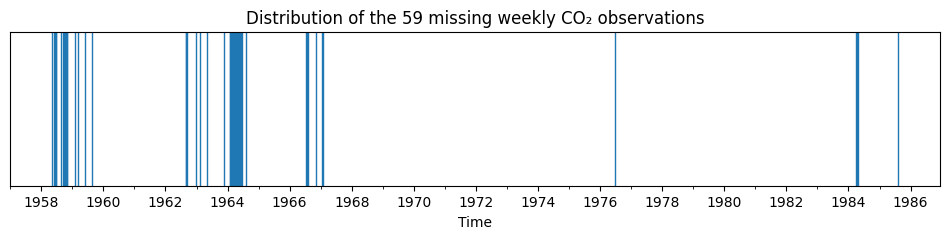

In [7]:
# visual plot of location of missing values
fig, ax = plt.subplots(figsize=(12, 2))

ax.vlines(
    co2.index[missing],
    ymin=0,
    ymax=1,
    linewidth=1
)

ax.set_ylim(0, 1)
ax.set_yticks([]) # blank axis

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))

ax.set_xlabel("Time")
ax.set_title(f"Distribution of the {missing_count} missing weekly CO₂ observations");

The data contains 59 missing values, the temporal distribution of which is shown in the plot above. The plot shows that:

- Missing values are more frequent in the early data.
- There are several series of consecutive missing values, with the longest being in 1964.
- There are no missing values past 1986.

As we are working with a time series, we must consider how much *coverage* each year receives in the data.

We define the coverage of a given year as the proportion of observations present in the data compared with the possible observations given the defined weekly temporal resolution.

In [8]:
# compute size and number of non-null values for each year
year_missing = co2.resample('YE')['co2'].agg(size="size", count="count")
year_missing = year_missing.rename(index=lambda date: date.year) # rename to year

# compute number and proportion of missing values per year
year_missing["missing"] = year_missing["size"] - year_missing["count"]
year_missing["count_percent"] = 100 - (year_missing["missing"] / year_missing["size"] * 100)

# lambda function to compute number of weeks available for sample per year
year_count = lambda year: pd.date_range(f"{year}/01/01",
                                        f"{year}/12/31",
                                        freq='W-SAT').size

# compute coverage per year
year_missing['expected_timestamps'] = year_missing.index.map(year_count)
year_missing['coverage_percent'] = (year_missing['size'] / year_missing['expected_timestamps']) * 100

In [9]:
# display table ONLY for years with missing values / non-full coverage
year_missing.loc[
    (year_missing['missing'] > 0) | (year_missing['coverage_percent'] < 100),
    ['missing', 'count_percent', 'coverage_percent']
].round(2)

,missing,count_percent,coverage_percent
1958,15,62.50,76.92
1959,4,92.31,100.00
1962,4,92.31,100.00
1963,3,94.23,100.00
1964,21,59.62,100.00
1966,4,92.45,100.00
1967,2,96.15,100.00
1976,1,98.08,100.00
1984,4,92.31,100.00
1985,1,98.08,100.00


The table above displays the following information about the missing values and coverage for years containing missing values or where coverage is less than 100%:

- `missing` is the number of missing values
- `count_percent` is the proportion of non-missing values
- `coverage_percent` is the proportion of all possible weekly observations that are present in the data

The years 1958 and 1964 have the lowest percentage of non-missing values, as well as the largest amount of missing values. The year 1958 is the only year in the dataset not to have complete coverage.

The remaining years have full coverage and more than 90% of their values are present.

We conclude that both 1958 and 1964 must be treated with caution when it comes to analysis. They both contain extensive gaps in observations, and 1958 is incomplete.

### Cleaning the data

To fill the missing data we will use linear interpolation.

The reasoning for this is that observed weekly CO₂ concentration changes fairly smoothly over time, thus making a gradual transition between surrounding observations more plausible than holding the previous value constant (see `ffill`).

This is less reliable across longer gaps where interpolation may smooth genuine seasonal variation, particularly in the aformentioned years 1958 and 1964.

In [10]:
co2 = co2.interpolate(method='linear', axis=0)

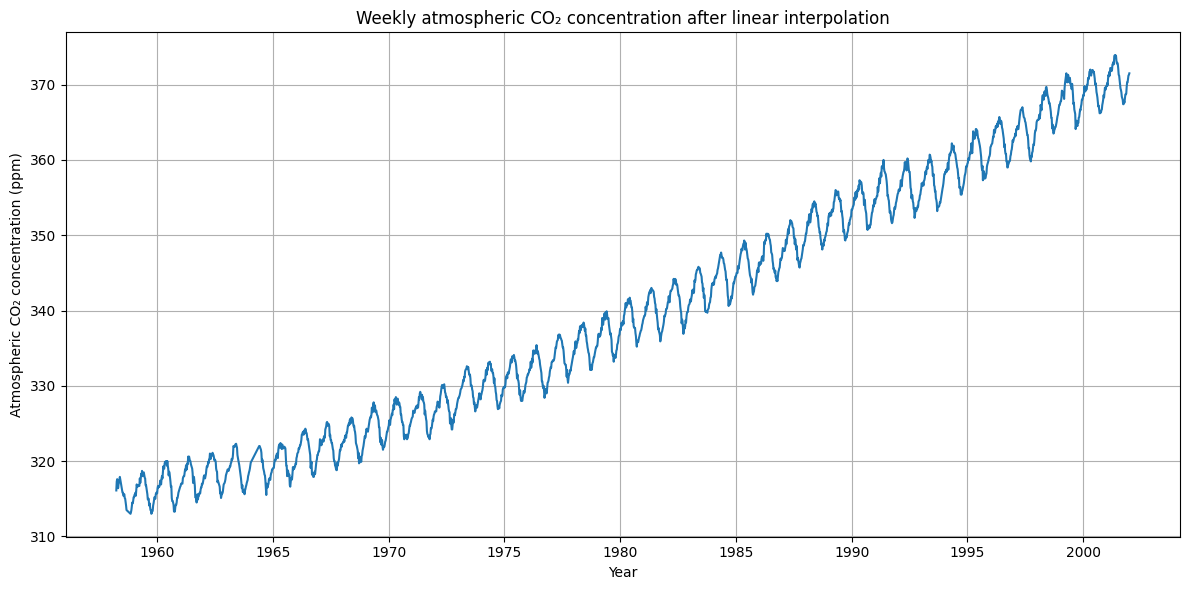

In [11]:
# plot interpolated data
fig, ax = plt.subplots(figsize=(12,6))
ax.plot(co2.index, co2['co2'])

ax.set_title("Weekly atmospheric CO₂ concentration after linear interpolation")
ax.set_xlabel("Year")
ax.set_ylabel("Atmospheric CO₂ concentration (ppm)")

ax.grid()
fig.tight_layout()

## Investigating the seasonal cycle

To isolate the seasonal variation from the long-term yearly changes in CO₂ concentration, we consider the difference of the each observation from the annual mean CO₂ concentration over the entire year of that observation - called the `anomaly`.

$$
\text{anomaly}=\text{weekly CO₂}−\text{annual mean CO}₂.
$$

To assess the prevalence of a yearly seasonal cycle throughout the dataset, we will aggregate data over multiple years by grouping the observations by the calendar month they took place in. Then, having computed the average anomaly for each calendar month, we will have a quantifiable measure of how much each month differs, on average, from its yearly mean.

The choice has been made to exclude two years from the data:

- 1958 due to both poor coverage (absent parts of the seasonal cycle) and large amount of interpolated values (smoothing of seasonal trends)
- 1964 due to a large amount of interpolated values (smoothing of seasonal trends)

In [12]:
# add useful columns
co2 = co2.assign(
    month=co2.index.month,
    year=co2.index.year
)

In [13]:
# calculate monthly avg anomalies
mask_years = (co2['year'] != 1958) & (co2['year'] != 1964) # exclude missing
co2.loc[mask_years, 'anomaly'] = co2['co2'] - co2.groupby('year')['co2'].transform('mean')
anomaly_avg = co2.groupby('month')['anomaly'].mean()

# assign to dummy year for plot
anomaly_avg = anomaly_avg.rename(
    index=lambda month: pd.to_datetime(f"2000/{month}/01")
)

In [14]:
# compute s.d. of yearly-monthly averages for error bars
month_avg = co2[mask_years].resample('MS')['anomaly'].mean()
month_std = month_avg.groupby(month_avg.index.month).std()

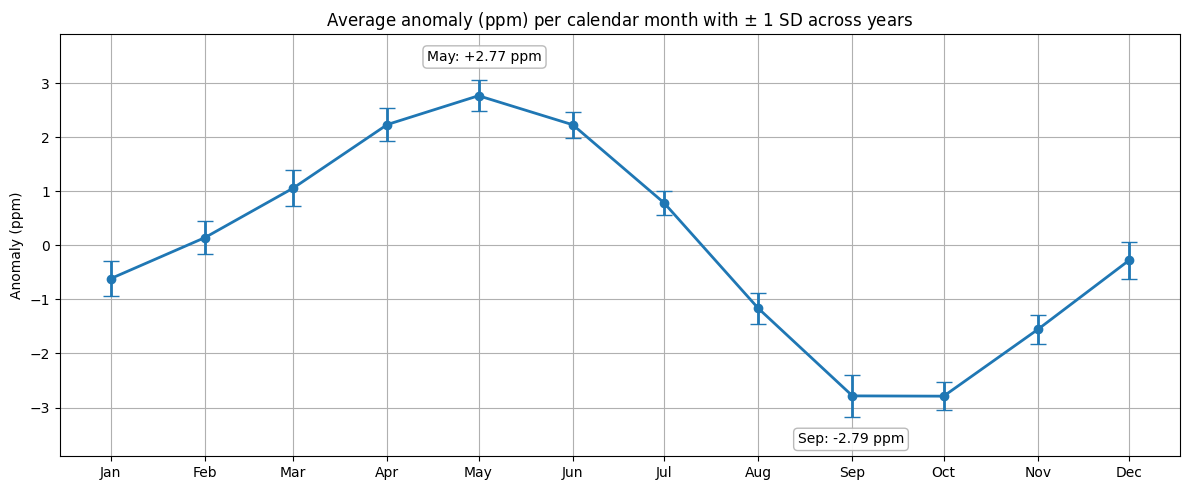

In [15]:
# plot monthly avg anomalies
fig, ax = plt.subplots(figsize=(12,5))

ax.grid()

ax.errorbar(
    anomaly_avg.index,
    anomaly_avg.values,
    yerr=month_std.values,
    fmt='o-',
    linewidth=2,
    capsize=6
)

# get minima and maxima, then annotate
min_val = (anomaly_avg.idxmin(), anomaly_avg.min())
max_val = (anomaly_avg.idxmax(), anomaly_avg.max())

box_prop = dict(
    boxstyle="round,pad=0.3",
    facecolor="white",
    edgecolor="0.7",
    alpha=0.9
)

ax.annotate(f"Sep: {min_val[1]:.2f} ppm", xy=min_val, xytext=(-105, -34), textcoords="offset points", bbox=box_prop)
ax.annotate(f"May: +{max_val[1]:.2f} ppm", xy=max_val, xytext=(-37, 25), textcoords="offset points", bbox=box_prop)

# x-axis setup
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

# y-axis setup
ax.set_ylim([-3.9, 3.9])
ax.set_ylabel("Anomaly (ppm)")

ax.set_title(r"Average anomaly (ppm) per calendar month with $\pm$ 1 SD across years")

fig.tight_layout()

The plot shows a clear cyclical pattern, with the average anomaly consistently rising above 0 ppm in spring, reaching a maximum at approximately +2.77 ppm in May, before consistently declining to a minimum of approximately -2.79 ppm in September; giving a peak-to-trough seasonal range of 5.56 ppm. This indicates the mean anomaly for each calendar follows a consistent annual cycle that is present over many years.

The error bars show that the year-to-year variability of each calendar month's anomaly is relatively small compared with the peak-to-trough range of 5.56 ppm. We can infer from this that the seasonal pattern in the calendar months is broadly consistent across the record and is unlikely to be driven by a small number of anomalous years.

There is clear evidence of a seasonal cycle in atmospheric CO₂ concentrations at Mauna Loa, characterised by increasing concentrations through spring, a peak in May, and a decline to a minimum in early autumn.

## How has CO₂ concentration changed with time?

To make useful comparisons in atmospheric CO₂ concentrations between different years, we need to be account for the effect of seasonal variation established previously. We can aggregate out the seasonal component by taking the annual mean.

For the same reasons as in the previous analysis, the years 1958 and 1964 are excluded.

In [16]:
# aggregated yearly means
yearly_avg = co2[mask_years].resample('YS')['co2'].mean()

In [17]:
# initial, final, growth and average growth rate
initial_val, initial_year = yearly_avg.iloc[0], yearly_avg.index[0].year
final_val, final_year = yearly_avg.iloc[-1], yearly_avg.index[-1].year

growth = final_val - initial_val
mean_annual_increase = growth / (final_year - initial_year)

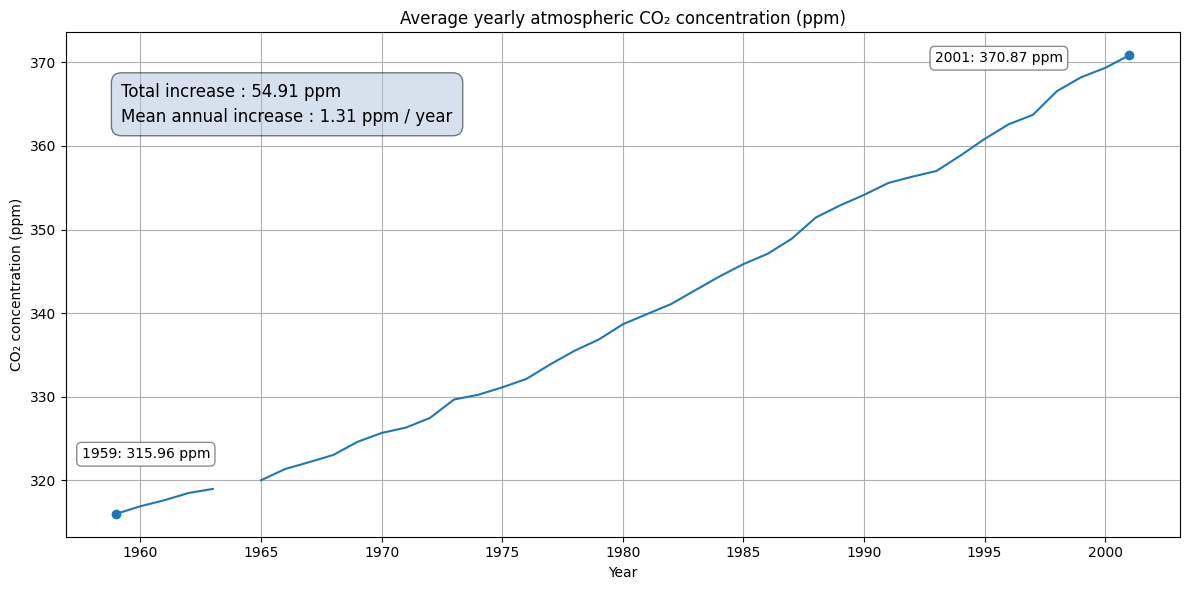

In [18]:
# plot yearly average against time
fig, ax = plt.subplots(figsize=(12,6))

# plot data
ax.plot(yearly_avg.index, yearly_avg.values)

# initial and final annotations
ax.scatter(yearly_avg.index[[0,-1]], [initial_val, final_val])

# bbox properties for annotation labels
annotation_props = dict(
    boxstyle="round,pad=0.35",
    facecolor="white",
    edgecolor="0.5",
    alpha=0.9
)

# points to annotate and offset
endpoints = [
    (yearly_avg.index[0], initial_val, (-25, 40)),
    (yearly_avg.index[-1], final_val, (-140, -5))
]

# plot annotations at endpoints with
for endpoint in endpoints:
    ax.annotate(
        f"{endpoint[0].year}: {endpoint[1]:.2f} ppm",
        xy=(endpoint[0], endpoint[1]),
        xytext=endpoint[2],
        textcoords="offset points",
        bbox=annotation_props,
    )

# text box string
textstr = '\n'.join([
    f"Total increase : {growth:.2f} ppm",
    f"Mean annual increase : {mean_annual_increase:.2f} ppm / year"
])

# text box bbox props
box_props = dict(
    boxstyle="round,pad=0.6",
    facecolor="lightsteelblue",
    alpha=0.5
)

# plot text box
ax.text(
    0.05, 0.90,
    textstr,
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    linespacing=1.5,
    bbox=box_props
)

# set up y-axis
ax.set_ylabel("CO₂ concentration (ppm)")

# set up x-axis
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlabel("Year")

# title and grid
ax.set_title("Average yearly atmospheric CO₂ concentration (ppm)")
ax.grid()

fig.tight_layout()

Over the period spanning from 1959 to 2001 there was a total increase of 54.91 ppm (~17%) in atmospheric CO₂ concentration. Over this period, the atmospheric CO₂ concentration increased, on average, by 1.31 ppm per year.

With exception to the missing data, the plot shows a smooth positive climb. This suggests a sustained long-term increase in atmospheric CO₂ concentration. The long-term increase remains evident after the seasonal cycle is suppressed by computing the annual mean.

There is strong evidence to suggest that atmospheric CO₂ concentration at Mauna Loa has increased substantially over the study period, and that this change is not due to a recurring seasonal cycle.

The sustained increase in atmospheric CO₂ concentration noted in the plot motivates the fitting and analysis of a linear model.

## Fitting a linear model

To evaluate whether the rate of increase in mean annual atmospheric CO₂ concentration has remained constant, we will fit a linear model to the data.

### Mathematical formulation

We define the variables as follows:

- $X$ = number of years elapsed since the first full year of data (1959)
- $Y$ = annual mean CO₂ concentration (ppm)

With $X$ as the explanatory variable and $Y$ as the response variable, we will fit the following linear model:

$$Y=\beta_0 + \beta_1X$$

where $(\beta_0, \beta_1)$ are coefficients resulting from the method of least squares.

### Fitting and assessing

To assess the linear model's fit, we will use the $R^2$ score and some residual analysis.

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
# prepare data for regression
# drop 1964
yearly_avg = yearly_avg.dropna()

# compute X (years elapsed) from index
years = yearly_avg.index.year.to_numpy()
X = (years - years.min()).reshape(-1,1)

# extract Y values
Y = yearly_avg.values

In [21]:
# fit linear model
lm = LinearRegression()
lm.fit(X, Y)

# compute R2 and residuals
lm_residuals = Y - lm.predict(X)
lm_r2 = lm.score(X, Y)

In [22]:
print(f"Intercept: {lm.intercept_:.3f}")
print(f"Slope: {lm.coef_[0]:.3f}")

Intercept: 311.688
Slope: 1.351


The fitted linear model estimates an average increase of 1.351 ppm per year over the span of the data.

This figure is very close to the endpoint-to-endpoint mean annual increase obtained previously (1.31 ppm / year).

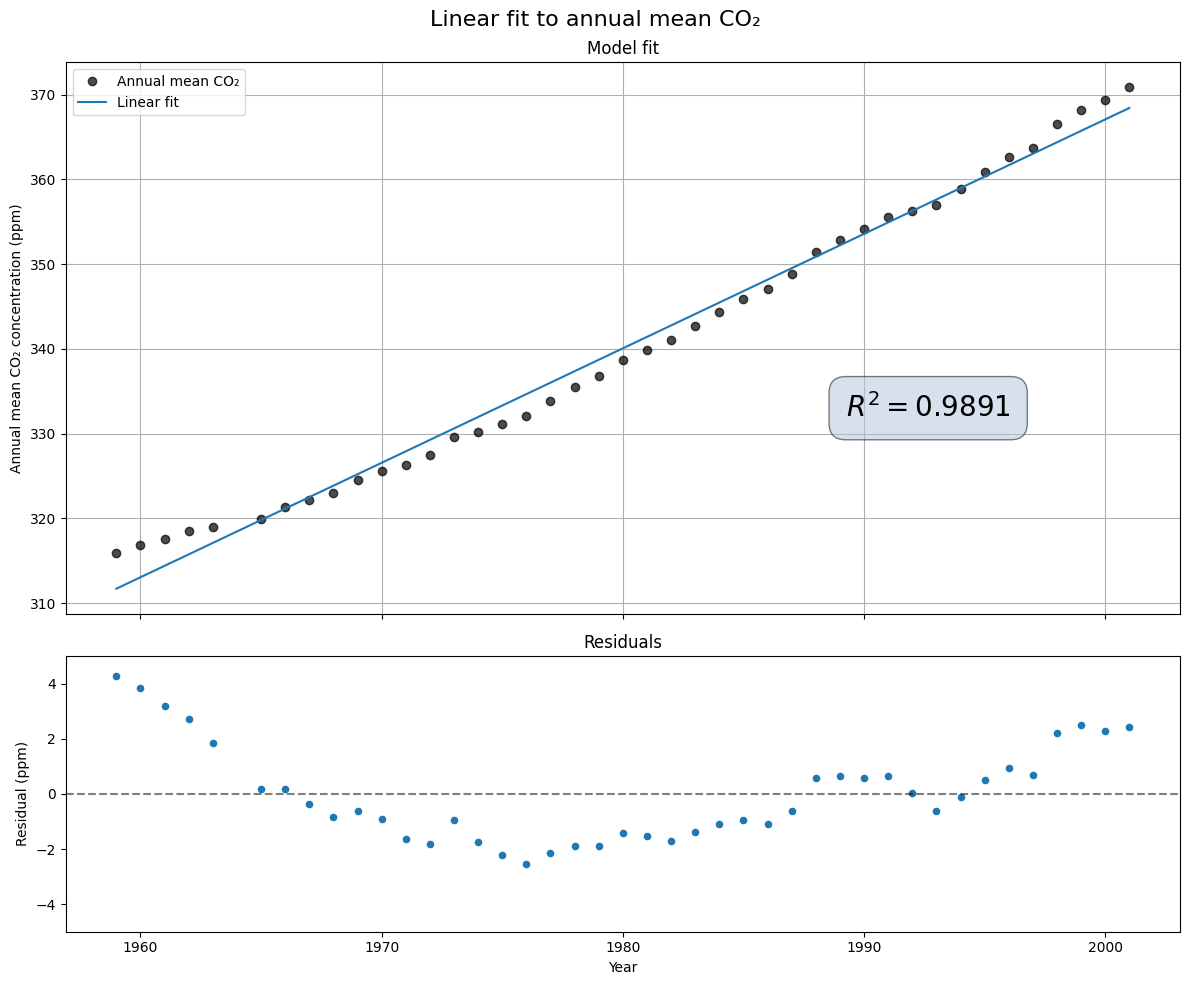

In [23]:
# plot residuals
fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[2,1], sharex=True, figsize=(12,10))

# plot data and linear fit
ax1.plot(years, Y, color='black', marker='o', linestyle='', alpha=0.7, label="Annual mean CO₂")
ax1.plot(years, lm.predict(X), label="Linear fit")

# plot residuals
ax2.axhline(color='black', linestyle='--', alpha=0.5)
ax2.scatter(years, lm_residuals, s=20, marker='o')

# set symmetrical limit for lower plot
lim = np.round(np.max(np.abs(ax2.get_ylim())))
ax2.set_ylim(-lim, lim)

# text box bbox props
box_props = dict(
    boxstyle="round,pad=0.6",
    facecolor="lightsteelblue",
    alpha=0.5
)

# plot R2
ax1.text(
    0.70, 0.4,
    f"$R^2={lm_r2:.4f}$",
    transform=ax1.transAxes,
    fontsize=20,
    verticalalignment="top",
    linespacing=1.5,
    bbox=box_props
)

# grids and legends
ax1.legend()
ax1.grid()

# labels and titles
fig.suptitle('Linear fit to annual mean CO₂', fontsize=16)
ax1.set_title("Model fit")
ax2.set_title("Residuals")

ax1.set_ylabel("Annual mean CO₂ concentration (ppm)")
ax2.set_ylabel("Residual (ppm)")
ax2.set_xlabel("Year")

fig.tight_layout();

The extremely high score of $R^2 = 0.9891$ indicates that the linear model accounts for a very large proportion of the variation in the data.

However, the curvature in the data is made apparent by the plot of the linear fit, and this is backed up by the non-random distribution of the residuals. The mean annual atmospheric CO₂ concentration is first underpredicted, then overpredicted, and then goes back to being underpredicted.

This implies that the data is not adequately explained by a linear model. We can interpret this to mean that the rate of increase of mean annual atmospheric CO₂ concentration was not constant between 1959 and 2001.

To help support this conclusion, the fitting and analysis of a model that can account for curvature may provide some insight.

### Quadratic model

The systematic curvature of the residuals of the linear model motivates the fitting of a quadratic model to assess whether allowing a variable rate of increase will dampen the residual structure.

We will fit a quadratic model of the form:

$$Y=\beta_0 + \beta_1 X + \beta_2 X^2$$

where $(\beta_0, \beta_1, \beta_2)$ are coefficients resulting from the method of least squares.

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [25]:
# create quadratic regression model
qm = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

In [26]:
# fit quadratic model
qm.fit(X, Y)

# compute R2 and residuals
qm_r2 = qm.score(X,Y)
qm_residuals = Y-qm.predict(X)

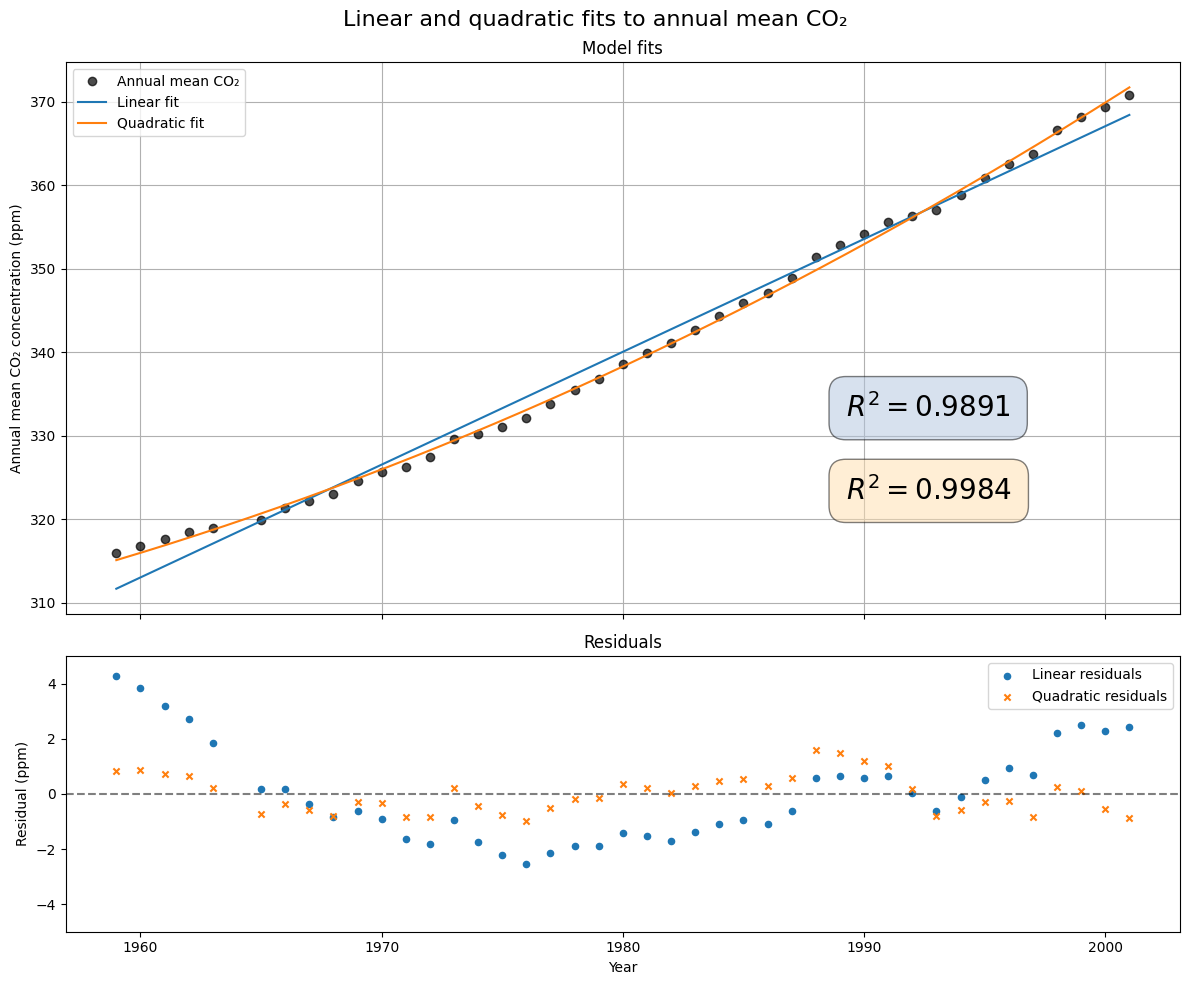

In [27]:
# plot quadratic fit and residuals together with linear fit and residuals
fig, (ax1, ax2) = plt.subplots(2, 1, height_ratios=[2,1], sharex=True, figsize=(12,10))

# create smooth x-values for plotting fitted curves
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
years_plot = X_plot.ravel() + years.min()

# plot data and fitted models
ax1.plot(years, Y, color='black', marker='o', linestyle='', alpha=0.7, label="Annual mean CO₂")
ax1.plot(years_plot, lm.predict(X_plot), label="Linear fit")
ax1.plot(years_plot, qm.predict(X_plot), label="Quadratic fit")

# plot residuals
ax2.axhline(color='black', linestyle='--', alpha=0.5)
ax2.scatter(years, lm_residuals, s=20, marker='o', label="Linear residuals")
ax2.scatter(years, qm_residuals, s=20, marker='x', label="Quadratic residuals")

# set symmetrical limit for lower plot
lim = np.round(np.max(np.abs(ax2.get_ylim())))
ax2.set_ylim(-lim, lim)

# grids and legends
ax1.legend()
ax1.grid()
ax2.legend()

# plotting boxes
endpoints = [
    (lm_r2, 'lightsteelblue', (0.7, 0.4)),
    (qm_r2, 'navajowhite', (0.7, 0.25))
]

for endpoint in endpoints:
  # text box bbox props
  box_props = dict(
      boxstyle="round,pad=0.6",
      facecolor=endpoint[1],
      alpha=0.5
  )

  # plot R2
  ax1.text(
      *endpoint[2],
      f"$R^2={endpoint[0]:.4f}$",
      transform=ax1.transAxes,
      fontsize=20,
      verticalalignment="top",
      linespacing=1.5,
      bbox=box_props
  )

# labels and titles
fig.suptitle('Linear and quadratic fits to annual mean CO₂', fontsize=16)
ax1.set_title("Model fits")
ax2.set_title("Residuals")

ax1.set_ylabel("Annual mean CO₂ concentration (ppm)")
ax2.set_ylabel("Residual (ppm)")
ax2.set_xlabel("Year")

fig.tight_layout()

The quadratic model has a higher score of $R^2=0.9984$, meaning it accounts for a larger proportion of the variation in the data. However the difference in $R^2$ scores is not very large.

The residuals of the quadratic model appear more randomly distributed than those of the linear model, with the broad U-shaped residual structure being substantially reduced, yet there are still signs of a pattern in the quadratic residuals.
This indicates that the quadratic model captures the broad curvature more effectively, but also that it is not perfect.

Overall the analysis of both models is consistent with the idea that a constant linear trend is inadequate. A quadratic model better represents the broad acceleration of annual mean CO₂ concentration but it is nevertheless still incomplete.

We conclude that the rate of increase of annual mean CO₂ concentration was not constant over the study period, with the broad curvature being consistent with long-term acceleration. Neither model fully captures the structure of the data.

## Conclusions


### Seasonal cycles

A clear seasonal cycle was identified in atmospheric CO₂ concentration at Mauna Loa.

Mean monthly anomalies generally rise through spring to a maximum in May (+2.77 ppm), before declining to a minimum in September (-2.79 ppm), with a peak-to-trough range of approximately 5.56 ppm.

The relatively small year-to-year variability indicates that this seasonal pattern is broadly consistent across the record.


### Change in CO₂ concentrations

Atmospheric CO₂ concentration at Mauna Loa has substantially increased over the study period. After having isolated the long-term change in the data, we observe a total increase of 54.91 ppm in the annual mean atmospheric CO₂ concentration over the 42 elapsed years since 1959.


### Linearity

The annual mean atmospheric CO₂ concentration is not adequately described by a linear model.

Although the linear model accounts for a large proportion of the variation in the data, the strong U-shaped pattern in its residuals indicates that it fails to capture curvature in the long-term trend. A quadratic model was therefore fitted as a simple comparison model, which substantially reduced the broad residual curvature. However, some temporal structure in the residuals remained.

This indicates that the long-term rate of increase was not constant over the study period, and that a simple curved trend provides a better description than a constant linear trend.


### Final conclusion

Taken together, these results show that the atmospheric CO₂ concentration at Mauna Loa contains both a consistent seasonal component and a substantial long-term increase. The seasonal cycle oscillates around a rising baseline, and the long-term trend is not adequately represented by a constant rate of increase.


## Limitations

There are several limitations to this analysis:

- The dataset represents a single monitoring location, so the results describe temporal change at Mauna Loa rather than spatial variation in atmospheric CO₂ globally.

- Missing observations were estimated using linear interpolation, which becomes less reliable across longer gaps. Years with incomplete coverage or substantial missing data were excluded from analyses where representative annual or seasonal coverage was required. However, because the causes of the missing observations are not known, some uncertainty remains regarding whether the observed data are fully representative.

- The linear and quadratic models are empirical descriptions of the observed trend rather than physical models, and therefore do not identify the processes responsible for the observed changes.
